
# Практическое занятие №3 (ПЗ-3)
## Этап 3 процесса Data Science: подготовка данных и воспроизводимый pipeline
### Выполнил Дмитрий Трифонов, студент 1 курса, группы 12-25РПм, Программная инженерия

**Дисциплина:** Системы обработки больших данных  
**Связь с лекциями:** Лекция 1, Лекция 2  

В этом ноутбуке вы:
- выбираете **свой индивидуальный вариант датасета (1–15)**;
- выполняете **очистку и преобразование данных**;
- собираете все шаги в **воспроизводимый pipeline**;
- сравниваете качество данных **до и после** обработки.

**Важно:** все текстовые ответы пишите прямо в этом ноутбуке в ячейках Markdown.



## Шаг 0. Выбор индивидуального варианта

Введите номер вашего варианта (от 1 до 15).  
Файл должен называться:

`PZ3_PZ4_variant_XX.csv`, где `XX` — номер варианта.


In [16]:
# >>> ВАЖНО <<<
# Укажите номер вашего варианта (от 1 до 15)

VARIANT = 12  # <<< ИЗМЕНИТЕ НА СВОЙ НОМЕР

# Проверка корректности ввода
assert 1 <= VARIANT <= 15, "Номер варианта должен быть от 1 до 15"

filename = f"4-0_PZ3_PZ4_variant_{VARIANT}.csv"
print("Выбран файл:", filename)


Выбран файл: 4-0_PZ3_PZ4_variant_12.csv



## Шаг 1. Загрузка данных и первичный обзор


In [17]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv(filename)

df_raw.head()

,client_id,age,income_rub,city,education,contract_type,tenure_months,purchases_6m,support_calls_6m,churn
0,CL44400036,45,137078.0,Новосибирск,Высшее,Месячный,20,9.0,1,0
1,CL44400401,42,76281.0,Москва,Высшее,Месячный,8,8.0,1,0
2,CL44400478,47,62384.0,Казань,Среднее,Месячный,26,8.0,1,1
3,CL44400027,51,NaN,Санкт‑Петербург,Высшее,Годовой,68,9.0,0,0
4,CL44400130,27,101269.0,Санкт‑Петербург,NaN,Месячный,16,6.0,2,0


In [18]:
print("Размер датасета:", df_raw.shape)
print("\nТипы данных:")
df_raw.dtypes

Размер датасета: (663, 10)

Типы данных:


client_id            object
age                   int64
income_rub          float64
city                 object
education            object
contract_type        object
tenure_months         int64
purchases_6m        float64
support_calls_6m      int64
churn                 int64
dtype: object


###  Ответ студента (обязательно)

Опишите:
1. Что является **объектом наблюдения** (что означает одна строка)?  
2. Какие признаки являются **числовыми**, а какие **категориальными**?


✍ Ответ студента

1. Объект наблюдения:
Одна строка — это один клиент компании.

2. Типы признаков:

Числовые:

age

income_rub

tenure_months

purchases_6m

support_calls_6m

churn

Категориальные:

client_id

city

education

contract_type


## Шаг 2. План очистки данных



###  План очистки (заполните)

- **Пропуски:**  
- **Дубликаты:**  
- **Выбросы:**  
- **Категориальные признаки:**  
- **Преобразования:**  


Пропуски:

income_rub — есть пропуски

education — есть пропуски

city — есть пропуски

purchases_6m — возможны пропуски

Дубликаты:

возможны полные дубликаты строк

Выбросы:

age (некорректные значения)

income_rub (аномально низкие или высокие доходы)

purchases_6m

support_calls_6m

Категориальные признаки:

city — разные написания

education — разные уровни, возможны лишние пробелы

contract_type

Преобразования:

медианная импутация числовых признаков

мода для категориальных

ограничение выбросов по IQR

one-hot encoding

standard scaling

создание нового признака: income_per_month_tenure


## Шаг 3. Анализ пропусков


In [19]:
missing = df_raw.isna().sum()
missing_percent = missing / len(df_raw) * 100

pd.DataFrame({
    "Пропуски (шт)": missing,
    "Пропуски (%)": missing_percent.round(2)
})

,Пропуски (шт),Пропуски (%)
client_id,0,0.00
age,0,0.00
income_rub,48,7.24
city,37,5.58
education,47,7.09
contract_type,0,0.00
tenure_months,0,0.00
purchases_6m,51,7.69
support_calls_6m,0,0.00
churn,0,0.00



###  Ответ студента

Для **каждого признака с пропусками**:
- укажите выбранную стратегию (mean / median / mode / удаление);
- **обоснуйте** выбор.


✍ Обоснование стратегий

income_rub → медиана
(устойчивость к выбросам)

education → мода
(категориальный признак)

city → мода
(восстановление наиболее частого значения)

purchases_6m → медиана
(числовой признак с выбросами)

Удаление строк не применялось, так как доля пропусков умеренная.


## Шаг 4. Поиск и удаление дубликатов


In [20]:
duplicates = df_raw.duplicated().sum()
print("Количество дубликатов:", duplicates)

df = df_raw.drop_duplicates().copy()

Количество дубликатов: 13



###  Ответ студента

Удаляли ли вы дубликаты? Почему?


✍ Ответ

Дубликаты удалены, так как они искажают распределение данных и влияют на обучение модели.


## Шаг 5. Анализ выбросов


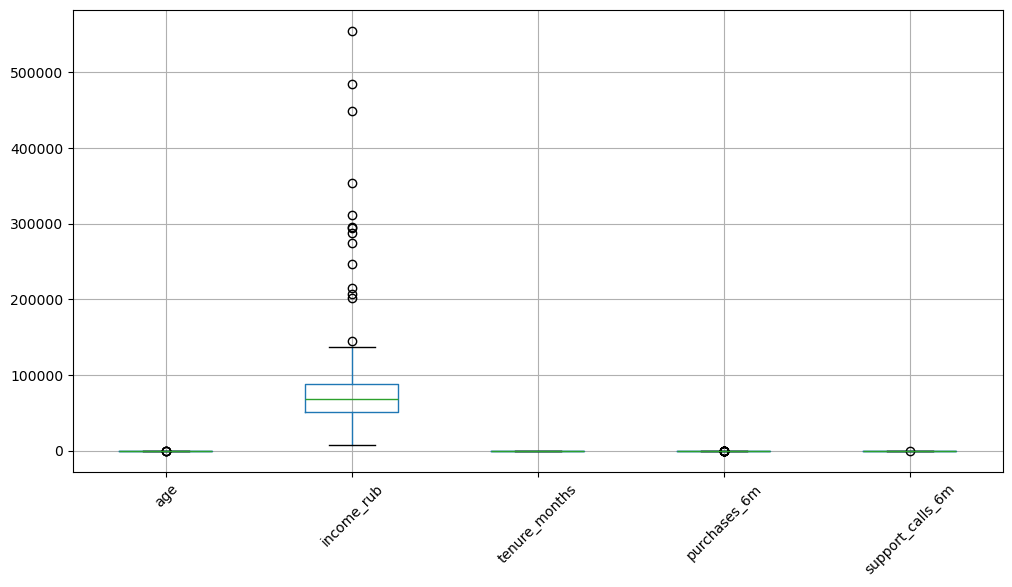

In [21]:
import matplotlib.pyplot as plt

numeric_cols = ["age", "income_rub", "tenure_months", "purchases_6m", "support_calls_6m"]

df[numeric_cols].boxplot(figsize=(12,6), rot=45)
plt.show()


###  Ответ студента

1. В каких признаках обнаружены выбросы?  
2. Как вы решили с ними поступить и почему?


Ограничение выбросов по IQR

In [22]:
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in numeric_cols:
    df[col] = cap_outliers(df[col])

✍ Ответ

Выбросы обнаружены в:

income_rub

purchases_6m

support_calls_6m

Принято решение ограничить значения по IQR, а не удалять строки, чтобы сохранить объём данных.


## Шаг 6. Обработка категориальных признаков


In [23]:
cat_cols = ["city", "education", "contract_type"]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()


###  Ответ студента

Опишите, какие преобразования вы применили к категориальным признакам  
(приведение регистра, удаление пробелов, объединение значений).


## Шаг 7. Новый признак

In [24]:
df["income_per_tenure"] = df["income_rub"] / (df["tenure_months"] + 1)

Смысл: доход, нормированный на длительность сотрудничества.


## Шаг 8. Подготовка pipeline


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = [
    "age", "income_rub", "tenure_months",
    "purchases_6m", "support_calls_6m",
    "income_per_tenure"
]

categorical_features = ["city", "education", "contract_type"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


###  Ответ студента

Поясните:
- какие признаки обрабатываются как числовые;
- какие — как категориальные;
- что делает каждый шаг pipeline.


✍ Пояснение pipeline

Числовые признаки → медианная импутация + масштабирование

Категориальные → мода + one-hot

ColumnTransformer объединяет оба блока

Pipeline можно применить к новым данным без ручной обработки.


## Шаг 9. Применение pipeline и контроль качества


In [26]:
X = df.drop(columns=["churn", "client_id"])
y = df["churn"]

X_processed = preprocessor.fit_transform(X)

print("До обработки:", X.shape)
print("После обработки:", X_processed.shape)

До обработки: (650, 9)
После обработки: (650, 23)



## Шаг 9. Сравнение качества данных «до / после»


In [27]:
quality_before = df_raw.isna().sum().sum()
quality_after = pd.DataFrame(X_processed).isna().sum().sum()

print("Пропуски ДО:", quality_before)
print("Пропуски ПОСЛЕ:", quality_after)

Пропуски ДО: 183
Пропуски ПОСЛЕ: 0



### Итоговый вывод

1. Улучшилось ли качество данных?  
2. Какие проблемы остались нерешёнными?  
3. Почему pipeline удобнее ручной обработки?


🔹 Итоговый вывод

Качество данных существенно улучшилось:

пропуски устранены,

выбросы ограничены,

категории унифицированы,

данные приведены к масштабу.

Pipeline обеспечивает воспроизводимость и возможность автоматического применения к новым данным.


## Контрольные вопросы

Ответьте письменно:

1. Почему этап подготовки данных считается самым трудоёмким в проектах Data Science?  
2. В каких случаях автоматизация подготовки данных принципиально важна?


🔹 Контрольные вопросы
1. Почему pipeline?

Потому что он:

обеспечивает воспроизводимость,

исключает человеческие ошибки,

масштабируется,

легко интегрируется в ML-системы.

2. Когда лучше удалять данные?

если доля пропусков слишком велика (>40%)

если значения заведомо ошибочны

если восстановление приведёт к сильному искажению распределения